In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/zero-day-android-botnet-detection-using-nn/BotnetFull.csv


In [4]:
df = pd.read_csv("/kaggle/input/zero-day-android-botnet-detection-using-nn/BotnetFull.csv")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1745821308.246124      89 service.cc:148] XLA service 0x79389c00a600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745821308.246769      89 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745821308.488372      89 cuda_dnn.cc:529] Loaded cuDNN version 90300


33/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8342 - loss: 0.7389 

I0000 00:00:1745821309.571782      89 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8777 - loss: 0.5920 - val_accuracy: 0.9752 - val_loss: 0.4249
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9689 - loss: 0.1953 - val_accuracy: 0.9711 - val_loss: 0.2952
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9842 - loss: 0.1354 - val_accuracy: 0.9711 - val_loss: 0.2170
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9799 - loss: 0.1233 - val_accuracy: 0.9711 - val_loss: 0.1694
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9767 - loss: 0.1278 - val_accuracy: 0.9835 - val_loss: 0.1498
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9868 - loss: 0.0968 - val_accuracy: 0.9752 - val_loss: 0.1266
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9869 - loss: 0.0974 - val_accuracy: 0.9752 - val_loss: 0.1204
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9903 - loss: 0.0773 - val_accuracy: 0.9752 - val_loss: 0.1128
Ep

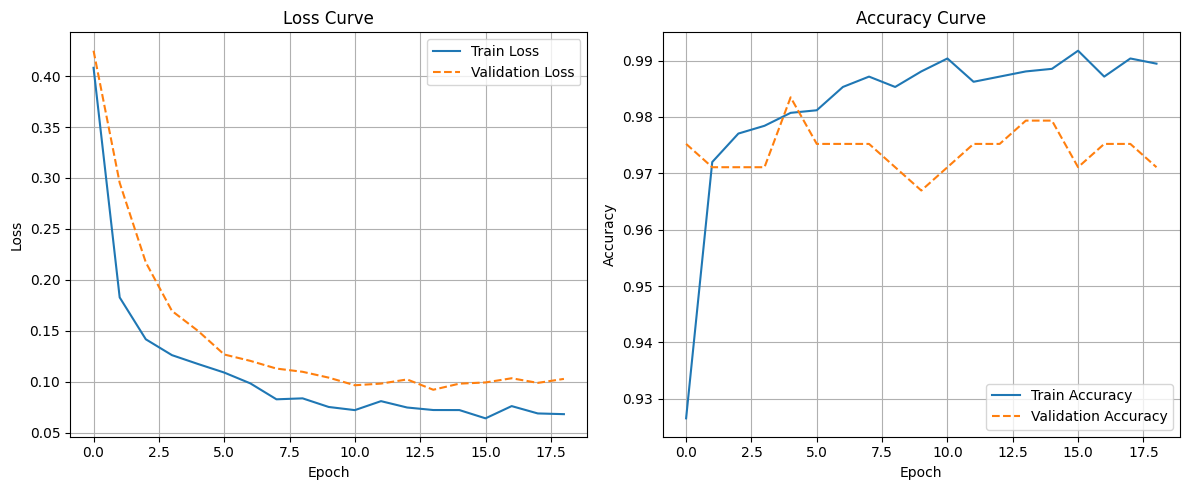

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2

# Step 1: Load and clean the dataset
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=41, stratify=y
)

# Step 5: Define the MLP model
model4 = Sequential([
    Dense(454, input_shape=(455,),kernel_regularizer=l2(0.001), use_bias=False),  # Hidden layer
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid',kernel_regularizer=l2(0.001))                      # Output layer
])

# Step 6: Compile the model4
optimizer = Adam(learning_rate=0.001)
model4.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model4
history = model4.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model4.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model4
# model2.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units', min_value=32, max_value=448), input_shape=(455,), use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    optimizer = hp.Choice('optimizer', values=['adam','rmsprop'])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=False
)

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=100
)

# Start tuning
tuner.search(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Trial 100 Complete [00h 00m 08s]
val_accuracy: 0.9816955924034119

Best val_accuracy So Far: 0.9836223721504211
Total elapsed time: 00h 12m 54s


In [10]:
tuner.get_best_hyperparameters()[0].values


{'units': 56, 'optimizer': 'rmsprop'}

In [11]:
print("hh")

hh


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt

def build_model(hp):
    model = Sequential()

    # First hidden layer
    model.add(Dense(
        hp.Int('units_0', min_value=32, max_value=128, step=32),
        input_shape=(455,),
        use_bias=False,
        kernel_regularizer=l2(hp.Float('l2_reg', 1e-4, 1e-2, sampling='log'))
    ))
    model.add(BatchNormalization())

    # Choose activation: relu or leaky_relu
    activation_choice = hp.Choice('activation', ['relu', 'leaky_relu'])
    if activation_choice == 'relu':
        model.add(Activation('relu'))
    else:
        model.add(LeakyReLU(alpha=0.01))

    model.add(Dropout(hp.Float('dropout_rate_0', 0.2, 0.5, step=0.1)))

    # Additional hidden layers
    for i in range(hp.Int('num_hidden_layers', 1, 5)):
        model.add(Dense(
            hp.Int(f'units_{i+1}', min_value=32, max_value=128, step=32),
            use_bias=False,
            kernel_regularizer=l2(hp.Float(f'l2_reg_{i+1}', 1e-4, 1e-2, sampling='log'))
        ))
        model.add(BatchNormalization())
        if activation_choice == 'relu':
            model.add(Activation('relu'))
        else:
            model.add(LeakyReLU(alpha=0.01))
        model.add(Dropout(hp.Float(f'dropout_rate_{i+1}', 0.2, 0.5, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    # Choose optimizer
    optimizer_choice = hp.Choice('optimizer', ['adam', 'rmsprop', 'nadam'])
    model.compile(optimizer=optimizer_choice, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate when stuck
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

# Train-test split properly
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=100,
    directory='tuner_dir',
    project_name='botnet_tuning'
)

# Search including batch size tuning
tuner.search(
    X_train_full, y_train_full,
    epochs=50,
    validation_split=0.2,
    batch_size=kt.HyperParameters().Choice('batch_size', [16, 32, 64, 128]),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate best model
best_model = tuner.get_best_models(num_models=1)[0]
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy of best model: {test_acc * 100:.2f}%")


Trial 44 Complete [00h 00m 25s]
val_accuracy: 0.9837545156478882

Best val_accuracy So Far: 0.9837545156478882
Total elapsed time: 00h 17m 49s

Search: Running Trial #45

Value             |Best Value So Far |Hyperparameter
128               |64                |units_0
0.0028936         |0.0027365         |l2_reg
leaky_relu        |leaky_relu        |activation
0.3               |0.4               |dropout_rate_0
4                 |4                 |num_hidden_layers
32                |64                |units_1
0.00092489        |0.000135          |l2_reg_1
0.3               |0.2               |dropout_rate_1
adam              |nadam             |optimizer
32                |96                |units_2
0.0023783         |0.00020903        |l2_reg_2
0.4               |0.4               |dropout_rate_2
96                |64                |units_3
0.00063125        |0.00035764        |l2_reg_3
0.3               |0.4               |dropout_rate_3
32                |32                |uni